# Model Tuning
### 최적 모델로 선정한 CatBoost 파라미터 및 threshold 튜닝

In [1]:
import warnings
warnings.filterwarnings("ignore")

import itertools
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix, 
    precision_recall_curve
)

from catboost import CatBoostClassifier

In [2]:
# =========================
# 데이터 지정 (top30)
# =========================
DATA_DIR = Path('../Data')
train_df = pd.read_csv(DATA_DIR / "train_selection_top30.csv")
test_df = pd.read_csv(DATA_DIR / "test_selection_top30.csv")

target_col = "fraud"

# =========================
# Train / Test 분리
# =========================

X = train_df.drop(columns=[target_col]).copy()
y = train_df[target_col].copy()

X_test = test_df.copy()   # test에는 target 없음

print("Train X shape:", X.shape)
print("Train y shape:", y.shape)
print("Test X shape :", X_test.shape)
print("Positive ratio:", y.mean().round(4))

Train X shape: (18000, 30)
Train y shape: (18000,)
Test X shape : (12000, 30)
Positive ratio: 0.1582


In [3]:
# 이진 분류 모델 성능 평가 함수
def evaluate_binary_classification(y_true, y_prob, threshold=0.4):
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "f1": f1_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0)
    }

In [4]:
# CatBoost 단일 모델에 대해 Stratified K-Fold CV를 수행하고 OOF 예측 및 성능 지표 계산
def run_catboost_cv_single(
    X,
    y,
    cat_params,
    n_splits=5,
    random_state=2542,
    threshold=0.4,
    early_stopping_rounds=300,
    verbose_eval=False
):
    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    oof_pred = np.zeros(len(X))
    fold_metrics = []
    fitted_models = []

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), 1):
        X_train = X.iloc[train_idx].copy()
        X_valid = X.iloc[valid_idx].copy()
        y_train = y.iloc[train_idx].copy()
        y_valid = y.iloc[valid_idx].copy()

        neg = (y_train == 0).sum()
        pos = (y_train == 1).sum()
        scale_pos_weight = (neg / pos) * 1.1 if pos > 0 else 1.0

        model = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            random_seed=random_state,
            scale_pos_weight=scale_pos_weight,
            verbose=0,
            **cat_params
        )

        model.fit(
            X_train,
            y_train,
            eval_set=(X_valid, y_valid),
            use_best_model=True,
            early_stopping_rounds=early_stopping_rounds,
            verbose=False
        )

        valid_prob = model.predict_proba(X_valid)[:, 1]
        oof_pred[valid_idx] = valid_prob
        fitted_models.append(model)

        fold_result = evaluate_binary_classification(y_valid, valid_prob, threshold=threshold)
        fold_result["fold"] = fold
        fold_result["best_iteration"] = model.get_best_iteration()
        fold_metrics.append(fold_result)

        if verbose_eval:
            print(
                f"Fold {fold} | "
                f"ROC-AUC: {fold_result['roc_auc']:.4f} | "
                f"PR-AUC: {fold_result['pr_auc']:.4f} | "
                f"F1: {fold_result['f1']:.4f} | "
                f"Best Iter: {model.get_best_iteration()}"
            )

    oof_result = evaluate_binary_classification(y, oof_pred, threshold=threshold)
    fold_df = pd.DataFrame(fold_metrics)

    summary = {
        "oof_roc_auc": oof_result["roc_auc"],
        "oof_pr_auc": oof_result["pr_auc"],
        "oof_f1": oof_result["f1"],
        "oof_precision": oof_result["precision"],
        "oof_recall": oof_result["recall"],
        "cv_roc_auc_mean": fold_df["roc_auc"].mean(),
        "cv_roc_auc_std": fold_df["roc_auc"].std(),
        "cv_pr_auc_mean": fold_df["pr_auc"].mean(),
        "cv_pr_auc_std": fold_df["pr_auc"].std(),
        "cv_f1_mean": fold_df["f1"].mean(),
        "cv_f1_std": fold_df["f1"].std(),
        "best_iteration_mean": fold_df["best_iteration"].mean()
    }

    return summary, oof_pred, fitted_models, fold_df

In [5]:
# 파라미터 딕셔너리로부터 가능한 모든 하이퍼파라미터 조합 생성
def make_param_grid(param_grid):
    keys = list(param_grid.keys())
    values = list(param_grid.values())

    combinations = []
    for combo in itertools.product(*values):
        combinations.append(dict(zip(keys, combo)))

    return combinations

In [6]:
# 주어진 파라미터 범위에서 랜덤 샘플링을 통해 중복 제거된 하이퍼파라미터 조합 리스트를 생성
def make_random_param_list(param_grid, n_iter=20, random_state=2542):
    rng = random.Random(random_state)

    combinations = []
    for _ in range(n_iter):
        sampled = {}
        for k, v in param_grid.items():
            sampled[k] = rng.choice(v)
        combinations.append(sampled)

    # 중복 제거
    unique_combinations = []
    seen = set()

    for params in combinations:
        key = tuple(sorted(params.items()))
        if key not in seen:
            seen.add(key)
            unique_combinations.append(params)

    return unique_combinations

In [7]:
# Grid/Random Search를 통해 CatBoost 하이퍼파라미터를 CV 기반으로 탐색하고 최적 파라미터 및 모델을 반환
def tune_catboost_cv(
    X,
    y,
    param_grid,
    search_type="grid",
    n_iter=20,
    n_splits=5,
    random_state=2542,
    threshold=0.4,
    early_stopping_rounds=300,
    sort_metric="oof_pr_auc",
    verbose_eval=False
):
    if search_type == "grid":
        param_list = make_param_grid(param_grid)
    elif search_type == "random":
        param_list = make_random_param_list(
            param_grid=param_grid,
            n_iter=n_iter,
            random_state=random_state
        )
    else:
        raise ValueError("search_type은 'grid' 또는 'random' 이어야 합니다.")

    print(f"총 {len(param_list)}개 파라미터 조합 평가 시작")

    results = []
    best_oof_pred = None
    best_models = None
    best_fold_df = None

    for i, params in enumerate(param_list, 1):
        print(f"\n[{i}/{len(param_list)}] params = {params}")

        summary, oof_pred, fitted_models, fold_df = run_catboost_cv_single(
            X=X,
            y=y,
            cat_params=params,
            n_splits=n_splits,
            random_state=random_state,
            threshold=threshold,
            early_stopping_rounds=early_stopping_rounds,
            verbose_eval=verbose_eval
        )

        row = params.copy()
        row.update(summary)
        results.append(row)

        print(
            f" -> OOF ROC-AUC: {summary['oof_roc_auc']:.4f} | "
            f"OOF PR-AUC: {summary['oof_pr_auc']:.4f} | "
            f"OOF F1: {summary['oof_f1']:.4f}"
        )

    results_df = pd.DataFrame(results).sort_values(
        by=sort_metric, ascending=False
    ).reset_index(drop=True)

    best_params = results_df.iloc[0][list(param_grid.keys())].to_dict()

    print("\n최적 파라미터:")
    print(best_params)

    print("\n최적 성능:")
    print(results_df.iloc[0])

    # 최적 파라미터로 다시 한 번 모델 저장
    best_summary, best_oof_pred, best_models, best_fold_df = run_catboost_cv_single(
        X=X,
        y=y,
        cat_params=best_params,
        n_splits=n_splits,
        random_state=random_state,
        threshold=threshold,
        early_stopping_rounds=early_stopping_rounds,
        verbose_eval=verbose_eval
    )

    return results_df, best_params, best_oof_pred, best_models, best_fold_df

In [8]:
# CatBoost 튜닝에 사용할 하이퍼파라미터 탐색 범위 정의
param_grid = {
    "iterations": [3000, 5000, 10000],
    "learning_rate": [0.01, 0.03, 0.05],
    "depth": [4, 6, 8],
    "l2_leaf_reg": [1, 3, 5, 10],
    "subsample": [0.7, 0.8, 1.0],
    "bootstrap_type": ["Bernoulli"]
}

In [9]:
# Random Search 기반으로 CatBoost 하이퍼파라미터 튜닝을 수행하고 최적 결과를 출력
RANDOM_STATE = 2542

results_df_cat, best_params_cat, best_oof_pred_cat, best_models_cat, best_fold_df_cat = tune_catboost_cv(
    X=X,
    y=y,
    param_grid=param_grid,
    search_type="random",
    n_iter=20,
    n_splits=5,
    random_state=RANDOM_STATE,
    threshold=0.4,
    early_stopping_rounds=300,
    sort_metric="oof_pr_auc",
    verbose_eval=False
)

print(results_df_cat.round(4))

총 20개 파라미터 조합 평가 시작

[1/20] params = {'iterations': 3000, 'learning_rate': 0.01, 'depth': 8, 'l2_leaf_reg': 3, 'subsample': 1.0, 'bootstrap_type': 'Bernoulli'}
 -> OOF ROC-AUC: 0.6978 | OOF PR-AUC: 0.2881 | OOF F1: 0.3268

[2/20] params = {'iterations': 5000, 'learning_rate': 0.05, 'depth': 4, 'l2_leaf_reg': 5, 'subsample': 1.0, 'bootstrap_type': 'Bernoulli'}
 -> OOF ROC-AUC: 0.7084 | OOF PR-AUC: 0.2985 | OOF F1: 0.3364

[3/20] params = {'iterations': 3000, 'learning_rate': 0.05, 'depth': 6, 'l2_leaf_reg': 3, 'subsample': 1.0, 'bootstrap_type': 'Bernoulli'}
 -> OOF ROC-AUC: 0.7055 | OOF PR-AUC: 0.2941 | OOF F1: 0.3317

[4/20] params = {'iterations': 10000, 'learning_rate': 0.05, 'depth': 8, 'l2_leaf_reg': 10, 'subsample': 1.0, 'bootstrap_type': 'Bernoulli'}
 -> OOF ROC-AUC: 0.7009 | OOF PR-AUC: 0.2906 | OOF F1: 0.3295

[5/20] params = {'iterations': 10000, 'learning_rate': 0.01, 'depth': 8, 'l2_leaf_reg': 5, 'subsample': 1.0, 'bootstrap_type': 'Bernoulli'}
 -> OOF ROC-AUC: 0.6986 | OOF

### 최적 파라미터 결정
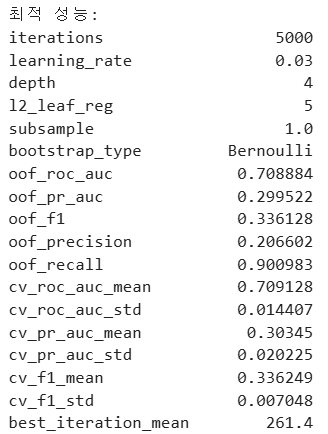

In [10]:
# 주어진 threshold 기준으로 이진 분류 성능 및 confusion matrix 관련 지표를 계산
def evaluate_threshold(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "threshold": threshold,
        "roc_auc": roc_auc_score(y_true, y_prob),   # threshold와 무관
        "pr_auc": average_precision_score(y_true, y_prob),  # threshold와 무관
        "f1": f1_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
        "pred_positive_rate": y_pred.mean()
    }

In [11]:
# 다양한 threshold에 대해 성능 지표를 계산하여 비교용 테이블로 반환
def threshold_search_table(y_true, y_prob, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.10, 0.91, 0.05)

    rows = []
    for t in thresholds:
        rows.append(evaluate_threshold(y_true, y_prob, t))

    results_df = pd.DataFrame(rows)
    return results_df

In [12]:
# 다양한 threshold 값에 대해 OOF 예측 성능을 계산하고 결과를 출력
threshold_df = threshold_search_table(
    y_true=y,
    y_prob=best_oof_pred_cat,
    thresholds=np.arange(0.10, 0.91, 0.05)
)

print(threshold_df.round(4))

    threshold  roc_auc  pr_auc      f1  precision  recall    tp     fp     tn  \
0        0.10   0.7089  0.2995  0.2760     0.1601  1.0000  2848  14943    209   
1        0.15   0.7089  0.2995  0.2809     0.1634  0.9989  2845  14566    586   
2        0.20   0.7089  0.2995  0.2877     0.1682  0.9944  2832  14009   1143   
3        0.25   0.7089  0.2995  0.2963     0.1742  0.9891  2817  13350   1802   
4        0.30   0.7089  0.2995  0.3053     0.1811  0.9716  2767  12513   2639   
5        0.35   0.7089  0.2995  0.3190     0.1920  0.9428  2685  11302   3850   
6        0.40   0.7089  0.2995  0.3361     0.2066  0.9010  2566   9854   5298   
7        0.45   0.7089  0.2995  0.3500     0.2223  0.8223  2342   8193   6959   
8        0.50   0.7089  0.2995  0.3615     0.2415  0.7180  2045   6422   8730   
9        0.55   0.7089  0.2995  0.3668     0.2653  0.5938  1691   4682  10470   
10       0.60   0.7089  0.2995  0.3588     0.2979  0.4512  1285   3029  12123   
11       0.65   0.7089  0.29

In [13]:
# F1 기준 최적 threshold
best_f1_row = threshold_df.sort_values("f1", ascending=False).iloc[0]

print("F1 기준 최적 threshold")
print(best_f1_row.round(4))

F1 기준 최적 threshold
threshold                 0.5500
roc_auc                   0.7089
pr_auc                    0.2995
f1                        0.3668
precision                 0.2653
recall                    0.5938
tp                     1691.0000
fp                     4682.0000
tn                    10470.0000
fn                     1157.0000
pred_positive_rate        0.3541
Name: 9, dtype: float64


In [14]:
# recall 제약 조건을 만족하는 threshold 중에서 precision과 F1이 가장 높은 최적 threshold
recall_constraint = 0.8

candidate_df = threshold_df[threshold_df["recall"] >= recall_constraint].copy()
best_recall_priority_row = candidate_df.sort_values(
    ["precision", "f1"], ascending=False
).iloc[0]

print(f"Recall >= {recall_constraint} 조건에서 최적 threshold")
print(best_recall_priority_row.round(4))

Recall >= 0.8 조건에서 최적 threshold
threshold                0.4500
roc_auc                  0.7089
pr_auc                   0.2995
f1                       0.3500
precision                0.2223
recall                   0.8223
tp                    2342.0000
fp                    8193.0000
tn                    6959.0000
fn                     506.0000
pred_positive_rate       0.5853
Name: 7, dtype: float64


In [16]:
# PR curve 기반으로 F1 score가 최대가 되는 최적 threshold 탐색
def find_best_threshold_from_pr_curve(y_true, y_prob):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)

    precisions = precisions[:-1]
    recalls = recalls[:-1]

    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-12)

    pr_curve_df = pd.DataFrame({
        "threshold": thresholds,
        "precision": precisions,
        "recall": recalls,
        "f1": f1_scores
    })

    best_idx = pr_curve_df["f1"].idxmax()
    best_row = pr_curve_df.loc[best_idx]

    return pr_curve_df, best_row

In [17]:
# PR curve 기반 F1 최적 threshold
pr_curve_df, best_pr_row = find_best_threshold_from_pr_curve(
    y_true=y,
    y_prob=best_oof_pred_cat
)

print("PR curve 기반 F1 최적 threshold")
print(best_pr_row.round(4))

PR curve 기반 F1 최적 threshold
threshold    0.5575
precision    0.2728
recall       0.5790
f1           0.3709
Name: 11956, dtype: float64


In [18]:
# precision 제약 조건을 만족하는 threshold 중에서 precision과 F1이 가장 높은 최적 threshold
target_precision = 0.25

candidate_pr_df2 = pr_curve_df[pr_curve_df["precision"] >= target_precision].copy()
best_high_precision_row = candidate_pr_df2.sort_values(
    ["recall", "f1"], ascending=False
).iloc[0]

print(f"Precision >= {target_precision} 조건에서 최적 threshold")
print(best_high_precision_row.round(4))

Precision >= 0.25 조건에서 최적 threshold
threshold    0.5188
precision    0.2503
recall       0.6763
f1           0.3653
Name: 10304, dtype: float64


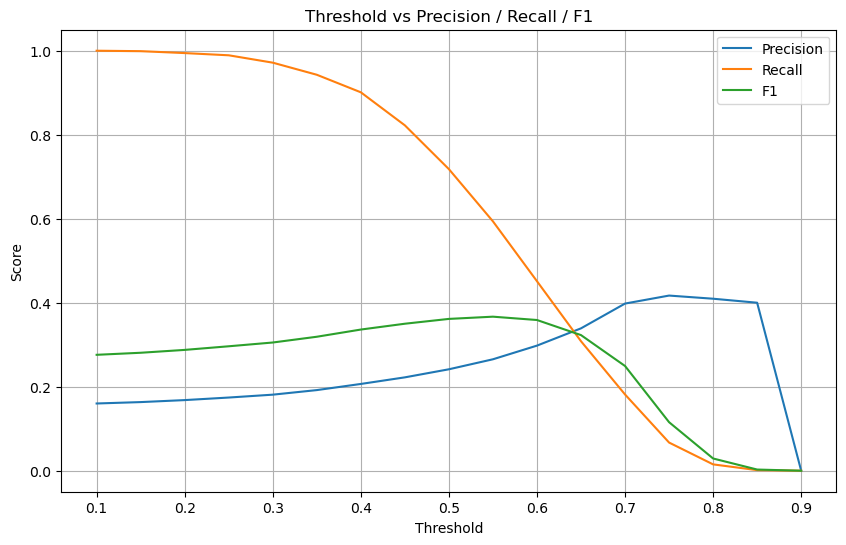

In [19]:
# threshold 변화에 따른 Precision / Recall / F1 관계 시각화
plt.figure(figsize=(10, 6))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Precision / Recall / F1")
plt.legend()
plt.grid(True)
plt.show()

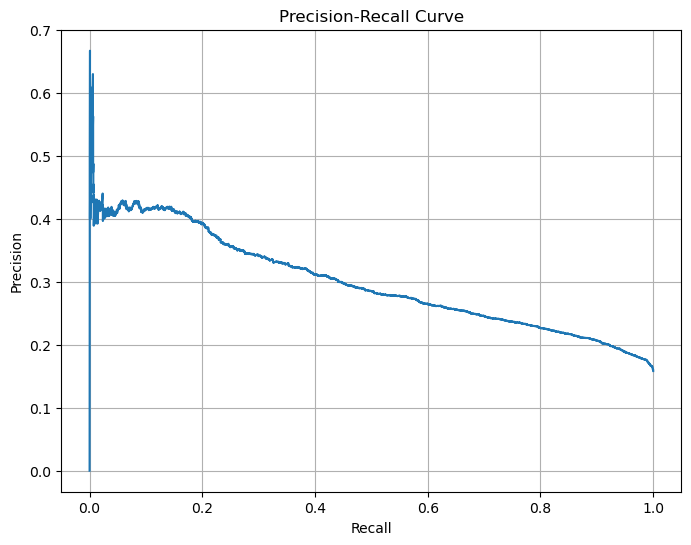

In [20]:
# PR Curve 시각화
plt.figure(figsize=(8, 6))
plt.plot(pr_curve_df["recall"], pr_curve_df["precision"])
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.show()

### 본 모델은 OOF ROC-AUC 0.7089, PR-AUC 0.2995를 달성하였으며, 다양한 threshold 전략(F1 최적, Precision 제약, High Recall)을 비교한 결과, 사기 탐지의 특성을 반영하여 Recall 82%를 확보하는 threshold(0.45)를 최종 운영 기준으로 선정